In [1]:
import cvxpy as cp
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import zap
from zap.importers.pypsa import load_pypsa_network, parse_buses
import os
from pathlib import Path
import pypsa
from zap.devices import ACLine
import pandas as pd
import geopandas as gpd
from copy import deepcopy

In [2]:
LOAD_SCALING_FACTOR = 1.27
GEN_SCALING_FACTOR = 1.24
# GEN_SCALING_FACTOR = 1
LINE_SCALING_FACTOR = 0.7
INVESTMENT_NODE_CANDS = [32, 82, 50, 18, 15, 22, 43, 14, 23, 20, 94, 65, 78] # This is already sorted by land cost
# INVESTMENT_NODE_CANDS = [0, 82, 50, 18, 15, 22, 43, 14, 23, 20, 45, 65, 78] # This is already sorted by land cost

In [3]:
def upsample_zap_devices(devices, factor=4, original_timesteps=24):
    """Upsample time-varying attributes of zap devices by repeating each timestep."""
    upsampled_zap_devices = []
    for dev in devices:
        upsampled_dev = dev.sample_time(original_timesteps*factor, original_timesteps)
        upsampled_zap_devices.append(upsampled_dev)

    return upsampled_zap_devices

In [4]:
HOME_PATH = os.environ.get("HOME")
PYPSA_NETW0RK_PATH = (
    HOME_PATH + "/zap_data/pypsa-networks/western_small/network_2023.nc"
)
pn = pypsa.Network(PYPSA_NETW0RK_PATH)
snapshots = pn.generators_t.p_max_pu.index
# snapshot_data = snapshots[5616:5640]  # 8/23/21 # hourly
snapshot_data = snapshots[5448:5472]  # 8/16/21 # hourly

INFO:pypsa.io:Imported network network_2023.nc has buses, carriers, generators, lines, links, loads, storage_units


## Get terminal/bus cost information for possible investment candidate nodes

In [5]:
buses, buses_to_index = parse_buses(pn) # buses_to_index is dict of "pyspa_bus_name": "zap_terminal"
index_to_bus = {idx: name for name, idx in buses_to_index.items()}
pypsa_bus_names = [index_to_bus[i] for i in INVESTMENT_NODE_CANDS]

b = pn.buses.copy()
gdf = gpd.GeoDataFrame(
    b, geometry=gpd.points_from_xy(b["x"], b["y"]), crs="EPSG:4326"
)

county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
counties = gpd.read_file(county_url)[["STATEFP","COUNTYFP","GEOID","NAME","STATE_NAME","geometry"]]

j = gpd.sjoin(gdf, counties.to_crs("EPSG:4326"), how="left", predicate="within")

pn.buses["county_fips"] = j["GEOID"]  # 5-digit FIPS
pn.buses["county_name"] = j["NAME"]
pn.buses["state_fips"]  = j["STATEFP"]
pn.buses["state_name"]  = j["STATE_NAME"]

selected_node_fips = pn.buses.loc[pypsa_bus_names, "county_fips"]
county_land_lut_df = pd.read_csv("county_land_lut.csv")

In [6]:
sel = selected_node_fips.rename("county_fips").to_frame()
bus_to_terminal = {bus: term for term, bus in index_to_bus.items()}
sel["terminal"] = sel.index.map(bus_to_terminal)
sel["county_fips"] = sel["county_fips"].astype(str).str.zfill(5)
county_land_lut_df["county_fips"] = county_land_lut_df["county_fips"].astype(str).str.zfill(5)

sel = sel.merge(
    county_land_lut_df,
    left_on="county_fips",
    right_on="county_fips",
    how="left",
)

terminal_cost = (
    sel.groupby("terminal")["land_usd2017_per_acre"]
      .first()   # or .mean(), depending on what you want
      .sort_index()
)

In [7]:
CAPITAL_COSTS = np.array(sel.land_usd2017_per_acre)

## Convert PyPSA network to Zap

In [8]:
pypsa_kwargs = {}
pypsa_net, pypsa_devices = load_pypsa_network(
    pn, snapshot_data, power_unit=1.0e3, cost_unit=100.0, **pypsa_kwargs
)
print("Before upsample:", pypsa_devices[3].capital_cost[0])

pypsa_devices = upsample_zap_devices(pypsa_devices, factor=4, original_timesteps=24)
print("After upsample:", pypsa_devices[3].capital_cost[0])


Dropping empty generators.
Before upsample: [0.28181126]
After upsample: [1.12724503]


## Helper to create devices for planning problem

In [9]:
def create_planning_devices(pypsa_devices, planning_devices_params_dict):
    num_nodes = planning_devices_params_dict["num_nodes"]
    investment_node_cands = planning_devices_params_dict["investment_node_cands"]
    gen_scaling_factor = planning_devices_params_dict["gen_scaling_factor"]
    load_scaling_factor = planning_devices_params_dict["load_scaling_factor"]
    line_scaling_factor = planning_devices_params_dict["line_scaling_factor"]
    dc_nominal_capacity = planning_devices_params_dict["dc_nominal_capacity"]
    capital_costs = planning_devices_params_dict["capital_costs"]
    workload_profile = planning_devices_params_dict["workload_profile"]
    pypsa_net = planning_devices_params_dict["pypsa_net"]
    pypsa_devices = planning_devices_params_dict["pypsa_devices"]

    pypsa_devices_dc = deepcopy(pypsa_devices)

    # Scale load, gen, and line capacities
    pypsa_devices_dc[1].load *= load_scaling_factor
    pypsa_devices_dc[0].dynamic_capacity *= gen_scaling_factor
    pypsa_devices_dc[3].nominal_capacity *= line_scaling_factor
    pypsa_devices_dc[3].nominal_capacity[168] = 0.5
    pypsa_devices_dc[3].nominal_capacity[176] = 0.5
    pypsa_devices_dc[3].nominal_capacity[49] = 0.3

    # Select which nodes to build at
    dc_terminals = np.array(investment_node_cands[:num_nodes])
    n_dc = len(dc_terminals)
    dc_capital_costs = capital_costs[:n_dc]

    # Build nominal capacities for DC loads
    if np.isscalar(dc_nominal_capacity):
        nominal_capacity = np.full(n_dc, dc_nominal_capacity)
    else:
        nominal_capacity = dc_nominal_capacity

    # Build DCLoad object
    dcloads = zap.DataCenterLoad(
        num_nodes=pypsa_net.num_nodes,
        terminal=dc_terminals,
        profiles=n_dc*[workload_profile],
        nominal_capacity=nominal_capacity,
        linear_cost=np.ones(n_dc) * 0,
        settime_horizon=96,
        capital_cost=dc_capital_costs
    )

    pypsa_devices_dc.append(dcloads)
    return pypsa_devices_dc


## Run and analyze single node injection

In [10]:
def node_price_summaries(prices, topk=5, q=(0.95, 0.99)):
    """
    prices: [N,T]
    Returns dict of [N,] summaries over time for each node.
    """
    prices = np.asarray(prices)

    out = {}
    # percentiles over time (axis=1)
    for qq in q:
        out[f"p{int(qq*100)}"] = np.quantile(prices, qq, axis=1)

    # mean over time
    out["mean"] = prices.mean(axis=1)

    # mean of top-k hours (per node)
    k = int(topk)
    out[f"mean_top{k}"] = np.sort(prices, axis=1)[:, -k:].mean(axis=1)

    # max (what you're already doing)
    out["max"] = prices.max(axis=1)

    return out


In [11]:
# This will add a DC at the cheapest land cost node
planning_devices_params_dict = {
    "num_nodes": 1,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": 1, # GW
    "capital_costs": 0*CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}


planning_devices = create_planning_devices(pypsa_devices, planning_devices_params_dict)
base_outcome = pypsa_net.dispatch(
    planning_devices[:-1], time_horizon=96, solver=cp.CLARABEL, add_ground=False
)
single_node_outcome = pypsa_net.dispatch(
    planning_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

## Helper to run storage planning instance

In [12]:
def run_planning_experiment(pypsa_net, pypsa_devices_dc, planning_exp_params_dict):
    storage_expansion_factor = planning_exp_params_dict["storage_expansion_factor"]
    op_obj_selector = planning_exp_params_dict["op_obj_selector"]
    lmp_metric = planning_exp_params_dict.get("lmp_metric", "meanmax")
    lmp_beta = planning_exp_params_dict.get("lmp_beta", 1.0)
    num_iters = planning_exp_params_dict["num_iters"]

    # Create dispatch layer
    xstar = zap.DispatchLayer(
        pypsa_net,
        pypsa_devices_dc,
        parameter_names={"storage_capacity": (4, "power_capacity")},
        time_horizon=96,
        solver=cp.CLARABEL,
    )

    lower_bounds = {"storage_capacity": pypsa_devices_dc[4].power_capacity}
    upper_bounds = {"storage_capacity": storage_expansion_factor * pypsa_devices_dc[4].power_capacity}

    eta = {"storage_capacity": pypsa_devices_dc[4].power_capacity}

    # Create objectives
    inv_obj = zap.planning.InvestmentObjective(pypsa_devices_dc, xstar)
    if op_obj_selector == "dispatch":
        op_obj = zap.planning.DispatchCostObjective(pypsa_net, pypsa_devices_dc)
    elif op_obj_selector == "lmp":
        op_obj = zap.planning.LMPObjective(pypsa_net, pypsa_devices_dc, lmp_metric=lmp_metric, lmp_beta = lmp_beta)

    P = zap.planning.PlanningProblem(
        operation_objective=op_obj,
        investment_objective=inv_obj,
        layer=xstar,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
    )

    P.extra_projections = {}

    cost = P(**eta, requires_grad=True)
    grad = P.backward()

    state = P.solve(num_iterations=num_iters, initial_state=eta)
    

    return state, P

## Run a transmission planning experiment

In [73]:
# planning_devices already includes the DC single node injection we want

planning_exp_params_dict = {
    "storage_expansion_factor": 2.0,
    "op_obj_selector": "dispatch", # "dispatch" or "lmp" or "line_util" or "delta_line_util" which defaults to meanmax
    "lmp_metric": "sumsmoothmax",
    "lmp_beta": 1000.0,
    "num_iters": 10
}

planning_state, P = run_planning_experiment(pypsa_net, planning_devices, planning_exp_params_dict)


No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>
[0]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>
Starting iteration 1
{'storage_capacity': tensor([[5.1398],
        [4.2422],
        [8.7840],
        [7.1187],
        [4.6919],
        [3.8357],
        [7.2363],
        [6.1397],
        [3.8418],
        [2.7094],
        [3.2404],
        [7.5716],
        [7.2950],
        [7.4304],
        [6.1161],
        [7.2173],
        [5.8581],
        [4.8462],
        [5.7965],
        [5.8439],
        [7.0910

In [74]:
# Simulate the dispatch outcome with the planned line capacities
planned_line_capacities = planning_state[0]["storage_capacity"]
planned_devices = deepcopy(planning_devices)
planned_devices[4].power_capacity = planned_line_capacities

planned_outcome = pypsa_net.dispatch(
    planned_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

In [75]:
base_stats   = node_price_summaries(base_outcome.prices, topk=5)
single_stats = node_price_summaries(single_node_outcome.prices, topk=5)
dist_stats   = node_price_summaries(planned_outcome.prices, topk=5)

In [76]:
np.mean(dist_stats['max'])

0.5836054335198999

In [77]:
def line_util_metrics(flows_a, flows_b, line_nom_caps, thr=0.90):
    """
    Simple line-util comparison between scenario A and B.

    Args:
        flows_a: [L,T] line flows for scenario A
        flows_b: [L,T] line flows for scenario B
        line_nom_caps: [L,] nominal capacities
        thr: threshold for "critical" / near-binding (e.g., 0.90 or 0.95)

    Returns (dict):
        util_a, util_b: [L,T] utilizations
        peak_a, peak_b: [L]
        d_peak:         [L] = peak_a - peak_b   (positive => A has higher peak)
        hours_a, hours_b: [L] count of hours util>=thr
        d_hours:        [L] = hours_a - hours_b (positive => A has more near-binding hours)
        overload_a, overload_b: [L] mean exceedance above thr
        d_overload:     [L] = overload_a - overload_b
    """
    flows_a = np.asarray(flows_a)
    flows_b = np.asarray(flows_b)
    caps = np.asarray(line_nom_caps).reshape(-1)

    assert flows_a.shape == flows_b.shape
    L, T = flows_a.shape
    assert caps.shape[0] == L

    util_a = np.abs(flows_a) / caps[:, None]
    util_b = np.abs(flows_b) / caps[:, None]

    peak_a = util_a.max(axis=1)
    peak_b = util_b.max(axis=1)
    d_peak = peak_a - peak_b

    hours_a = (util_a >= thr).sum(axis=1)
    hours_b = (util_b >= thr).sum(axis=1)
    d_hours = hours_a - hours_b

    overload_a = np.maximum(util_a - thr, 0.0).mean(axis=1)
    overload_b = np.maximum(util_b - thr, 0.0).mean(axis=1)
    d_overload = overload_a - overload_b

    return {
        "util_a": util_a, "util_b": util_b,
        "peak_a": peak_a, "peak_b": peak_b, "d_peak": d_peak,
        "hours_a": hours_a, "hours_b": hours_b, "d_hours": d_hours,
        "overload_a": overload_a, "overload_b": overload_b, "d_overload": d_overload,
        "thr": thr
    }

def critical_lines_from_base(base_flows, single_flows, line_nom_caps, thr=0.90):
    """
    Step 1: define critical lines as those that become near-binding in the single-node case.
    We flag lines with peak utilization >= thr under single-node.

    Returns:
        crit_idx: indices of critical lines
        metrics: output of line_util_metrics(single, base, ...)
    """
    metrics = line_util_metrics(single_flows, base_flows, line_nom_caps, thr=thr)
    crit_idx = np.where(metrics["peak_a"] >= thr)[0]  # peak_a is single-node peak
    return crit_idx, metrics

In [43]:
##--- Usage ---##
line_nom_caps = planned_devices[3].nominal_capacity.squeeze()
planned_flows  = planned_outcome.power[3][1]   # [251,96]
base_flows    = base_outcome.power[3][1]          # [251,96]
threshold = 1.0

single_node_metrics = line_util_metrics(planned_flows, base_flows, line_nom_caps, thr=threshold)
print(f"Line-steps at threshold of {threshold}: {single_node_metrics['hours_a'].sum()}")

crit_idx, single_vs_base = critical_lines_from_base(
    base_flows=base_flows,
    single_flows=planned_flows,
    line_nom_caps=line_nom_caps,
    thr=threshold
)

print("num critical lines:", len(crit_idx))
# Now later you can evaluate distributed vs single (or distributed vs base) using line_util_metrics(...)
# dist_flows = dist_outcome.power[3][1]
# dist_vs_single = line_util_metrics(single_flows, dist_flows, line_nom_caps, thr=0.90)
# and then look at dist_vs_single["d_peak"][crit_idx], etc.


Line-steps at threshold of 1.0: 0
num critical lines: 0


In [44]:
base_outcome.prices.flatten()

array([0.43922211, 0.43922211, 0.43922212, ..., 0.13129716, 0.13129717,
       0.13129718])

Total Single Node Investment Cost: 115971.96
Total Battery Investment Cost: 0.01
Total Investment Cost: 115971.97
Dispatch Cost: 2267.92


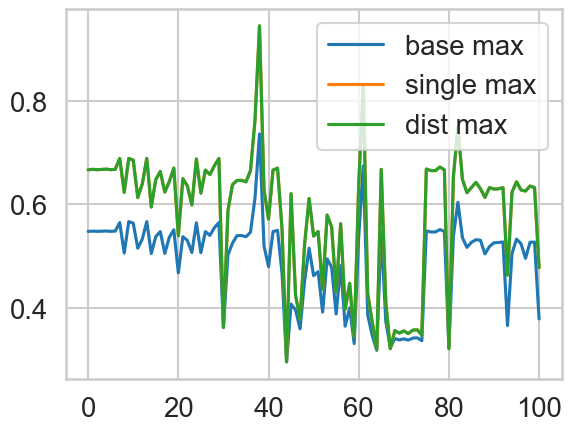

In [79]:
metric = "max" # mean, max, p95, p99, mean_top5
plt.plot(base_stats["p95"], label="base "+metric)
plt.plot(single_stats["p95"], label="single "+metric)
plt.plot(dist_stats["p95"], label="dist "+metric)
plt.legend()

dollars_per_mw_converter = 0.56
print(f"Total Single Node Investment Cost: {1000 * CAPITAL_COSTS[0] * dollars_per_mw_converter:.2f}")
print(f"Total Battery Investment Cost: {P.get_inv_cost() * 100 * 1000:.2f}")
print(f"Total Investment Cost: {1000*CAPITAL_COSTS[0] * dollars_per_mw_converter + P.get_inv_cost() * 100 * 1000:.2f}")
print(f"Dispatch Cost: {P.get_op_cost():.2f}")

(array([10.,  9.,  6.,  5., 15., 46.,  6.,  2.,  1.,  1.]),
 array([0.29568149, 0.34420869, 0.3927359 , 0.44126311, 0.48979031,
        0.53831752, 0.58684473, 0.63537193, 0.68389914, 0.73242634,
        0.78095355]),
 <BarContainer object of 10 artists>)

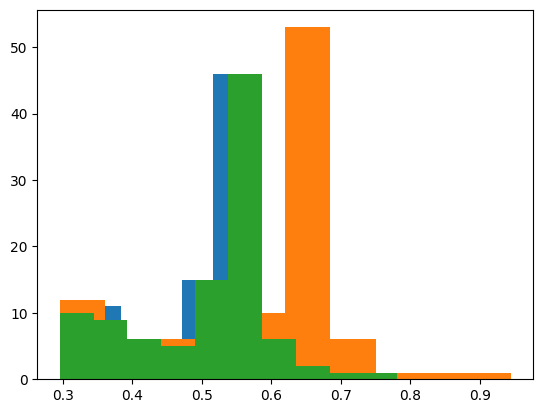

In [23]:
plt.hist(base_stats["p95"])
plt.hist(single_stats["p95"])
plt.hist(dist_stats["p95"])

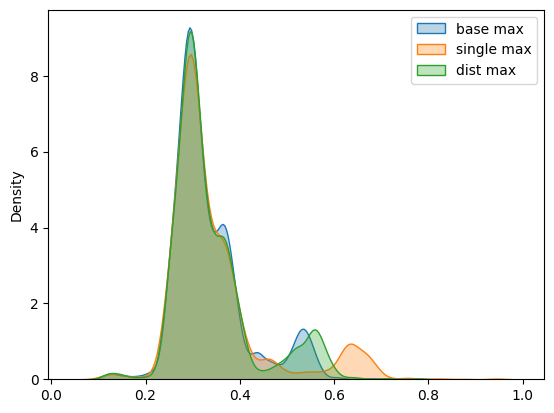

In [24]:
sns.kdeplot(base_outcome.prices.flatten(), label="base "+metric, fill=True, alpha=0.3)
sns.kdeplot(single_node_outcome.prices.flatten(), label="single "+metric, fill=True, alpha=0.3)
sns.kdeplot(planned_outcome.prices.flatten(), label="dist "+metric, fill=True, alpha=0.3)
plt.legend()

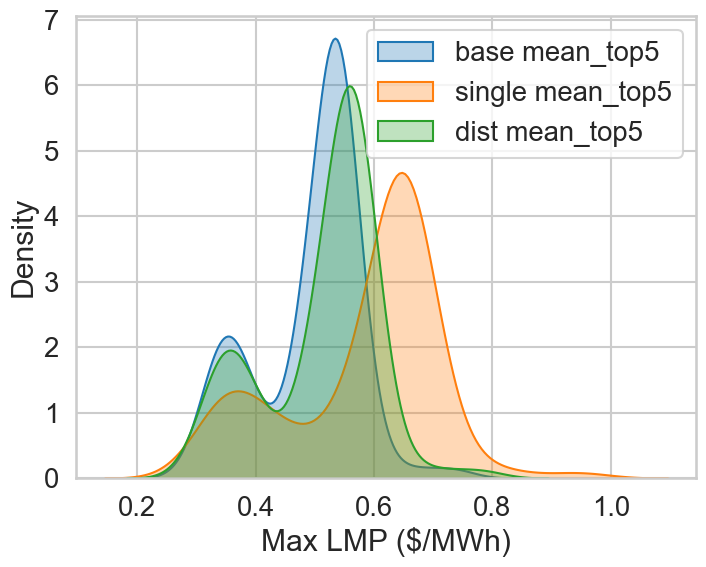

In [25]:
metric = "mean_top5"
sns.set_palette('tab10')
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.2)
plt.figure(figsize=(8,6))
sns.kdeplot(base_stats["mean_top5"], label="base "+metric, fill=True, alpha=0.3)
sns.kdeplot(single_stats["mean_top5"], label="single "+metric, fill=True, alpha=0.3)
sns.kdeplot(dist_stats["mean_top5"], label="dist "+metric, fill=True, alpha=0.3)
plt.xlabel("Max LMP ($/MWh)")
plt.legend()

In [ ]:
print(np.sum(planning_state[0]["storage_capacity"].squeeze(1) - pypsa_devices[4].power_capacity.squeeze(1)))
print(np.sum(pypsa_devices[4].power_capacity.squeeze(1)))
print(np.sum(planning_state[0]["storage_capacity"].squeeze(1)))


0.863497366805321
9.640200001850724
10.503697368656045


In [81]:
print(planned_devices[4].linear_cost)


[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
